In [62]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset




In [63]:
df1 = pd.read_csv(r"inputdata/EVUsersChargingData-high.csv")
df2 = pd.read_csv(r"inputdata/EVUsersChargingData-low.csv")
df = pd.concat([df1, df2], ignore_index=True)

In [64]:
df.head()

,No.,ArriveTime,DepartTime,Duration/min,ArriveSOC,DepartSOC,BatteryCapacity/kWh,Fast-chargingWillingness,DischargingWillingness,AverageChargingPower
0,1,05:27,06:27,60,0.4800,0.9,50,1,0.123598,21.000000
1,2,05:44,06:30,46,0.4440,0.9,40,1,0.457124,23.791304
2,3,05:47,06:47,60,0.4957,0.9,40,1,0.281148,16.170000
3,4,06:05,06:52,47,0.4367,0.9,40,1,0.287219,23.655319
4,5,06:07,08:48,161,0.4867,0.9,60,1,0.261950,9.242236


In [65]:

df.tail()

,No.,ArriveTime,DepartTime,Duration/min,ArriveSOC,DepartSOC,BatteryCapacity/kWh,Fast-chargingWillingness,DischargingWillingness,AverageChargingPower
1995,996,21:30,23:59,149,0.4880,0.9,40,1,0.634238,6.636242
1996,997,21:33,23:45,132,0.4707,0.9,60,1,0.466063,11.707727
1997,998,22:27,23:12,45,0.4727,0.9,40,1,0.069011,22.792000
1998,999,22:35,02:27,232,0.4966,0.9,50,1,0.535844,5.216379
1999,1000,23:16,03:40,264,0.4411,0.9,40,1,0.637081,4.171818


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   No.                       2000 non-null   int64  
 1   ArriveTime                2000 non-null   object 
 2   DepartTime                2000 non-null   object 
 3   Duration/min              2000 non-null   int64  
 4   ArriveSOC                 2000 non-null   float64
 5   DepartSOC                 2000 non-null   float64
 6   BatteryCapacity/kWh       2000 non-null   int64  
 7   Fast-chargingWillingness  2000 non-null   int64  
 8   DischargingWillingness    2000 non-null   float64
 9   AverageChargingPower      2000 non-null   float64
dtypes: float64(4), int64(4), object(2)
memory usage: 156.4+ KB


In [67]:
def time_to_float(t):
    hour, minute = map(int, t.split(":"))
    return hour + minute / 60


df['ArriveTime_float'] = df['ArriveTime'].apply(time_to_float)
df['DepartTime_float'] = df['DepartTime'].apply(time_to_float)

df['Arrive_sin'] = np.sin(2 * np.pi * df['ArriveTime_float'] / 24)
df['Arrive_cos'] = np.cos(2 * np.pi * df['ArriveTime_float'] / 24)
df['Depart_sin'] = np.sin(2 * np.pi * df['DepartTime_float'] / 24)
df['Depart_cos'] = np.cos(2 * np.pi * df['DepartTime_float'] / 24)

features = ["Arrive_sin", "Arrive_cos", "Depart_sin", 'Depart_cos', "Duration/min", "ArriveSOC", "DepartSOC",
            "BatteryCapacity/kWh", "Fast-chargingWillingness", "DischargingWillingness"]
target = ["AverageChargingPower"]

df_features = df[features]
df_target = df[target]


In [69]:
X_train, X_test, y_train, y_test = train_test_split(df_features, df_target, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)

if len(y_train.shape) == 1:
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
else:

    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

if len(y_test.shape) == 1:
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)
else:
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size)





     Arrive_sin  Arrive_cos  Depart_sin  Depart_cos  Duration/min  ArriveSOC  \
968   -0.182236    0.983255    0.515038    0.857167           166     0.4915   
240    0.304864   -0.952396   -0.173648   -0.984808           111     0.3550   
819   -0.948324    0.317305   -0.861629    0.507538            48     0.4625   
692   -0.976296   -0.216440   -0.967046    0.254602           109     0.4856   
420   -0.284015   -0.958820   -0.612217   -0.790690            85     0.3350   

     DepartSOC  BatteryCapacity/kWh  Fast-chargingWillingness  \
968        0.9                   50                         1   
240        0.9                   40                         1   
819        0.9                   40                         1   
692        0.9                   50                         1   
420        0.9                   40                         1   

     DischargingWillingness  
968                0.168746  
240                0.134263  
819                0.026365  
692     

In [24]:

input_channels = X_train_tensor.shape[1]
sequence_length = X_train_tensor.shape[2]
print(input_channels)
print(sequence_length)


class CNN1DRegression(nn.Module):
    def __init__(self, input_features=input_channels, output_classes=1, sequence_length=sequence_length):
        super(CNN1DRegression, self).__init__()

        self.conv1 = nn.Conv1d(in_channels=input_features, out_channels=16, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        with torch.no_grad():
            dummy_input = torch.randn(1, input_features, sequence_length)
            dummy_output = self.pool1(self.relu1(self.conv1(dummy_input)))
            dummy_output = self.pool2(self.relu2(self.conv2(dummy_output)))
            flattened_size = dummy_output.view(1, -1).shape[1]

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(flattened_size, 64)
        self.fc2 = nn.Linear(64, output_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.fc1(x)
        output = self.fc2(x)
        return output

1
10


In [18]:
#pick random seed for reproducibility
torch.manual_seed(0)
model = CNN1DRegression()


In [19]:
#set criteria of model to measure error.. how far off the prediction are from data
criterion = nn.MSELoss()
#choose optimizer we use Adam Optimizer
#learning rate (if error doesn't go down after bunch of epochs we might want to lower the learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [20]:
#train model

losses = []
rs = []
#decide how many epochs we want to train the model
epochs = 20

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    epoch_r2 = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        r2 = r2_score(y_batch.detach().cpu().numpy(), output.detach().cpu().numpy())
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_r2 += r2

    avg_loss = epoch_loss / len(train_loader)
    avg_r2 = epoch_r2 / len(train_loader)
    rs.append(avg_r2)
    losses.append(avg_loss)

    print(f"Epoch {epoch + 1}/{epochs} - Loss: {avg_loss:.4f}")
    print(f"Epoch {epoch + 1}/{epochs} - R2: {avg_r2:.4f}")


Epoch 1/20 - Loss: 51.4646
Epoch 1/20 - R2: 0.0673
Epoch 2/20 - Loss: 15.5860
Epoch 2/20 - R2: 0.7096
Epoch 3/20 - Loss: 8.2876
Epoch 3/20 - R2: 0.8460
Epoch 4/20 - Loss: 3.3872
Epoch 4/20 - R2: 0.9380
Epoch 5/20 - Loss: 2.2098
Epoch 5/20 - R2: 0.9591
Epoch 6/20 - Loss: 1.6607
Epoch 6/20 - R2: 0.9692
Epoch 7/20 - Loss: 1.4422
Epoch 7/20 - R2: 0.9735
Epoch 8/20 - Loss: 1.2447
Epoch 8/20 - R2: 0.9770
Epoch 9/20 - Loss: 1.0223
Epoch 9/20 - R2: 0.9813
Epoch 10/20 - Loss: 0.8803
Epoch 10/20 - R2: 0.9839
Epoch 11/20 - Loss: 0.8989
Epoch 11/20 - R2: 0.9834
Epoch 12/20 - Loss: 1.0548
Epoch 12/20 - R2: 0.9804
Epoch 13/20 - Loss: 1.8116
Epoch 13/20 - R2: 0.9668
Epoch 14/20 - Loss: 1.0382
Epoch 14/20 - R2: 0.9808
Epoch 15/20 - Loss: 0.8379
Epoch 15/20 - R2: 0.9848
Epoch 16/20 - Loss: 0.7698
Epoch 16/20 - R2: 0.9859
Epoch 17/20 - Loss: 0.9612
Epoch 17/20 - R2: 0.9822
Epoch 18/20 - Loss: 1.2110
Epoch 18/20 - R2: 0.9773
Epoch 19/20 - Loss: 0.6753
Epoch 19/20 - R2: 0.9875
Epoch 20/20 - Loss: 0.6798
E

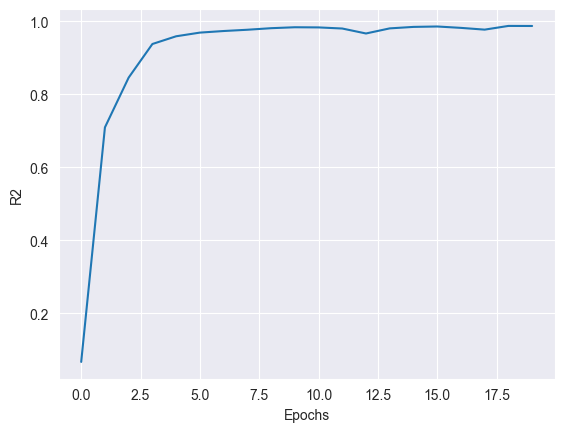

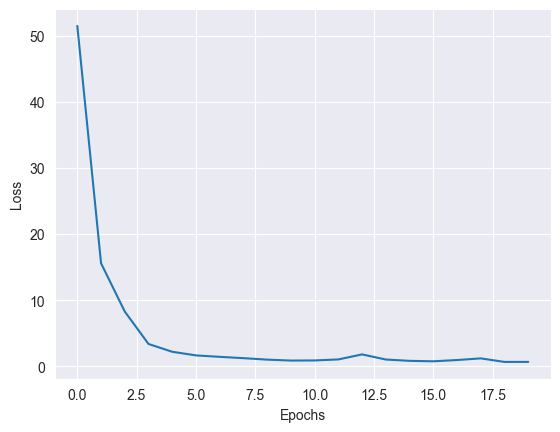

In [21]:
#graph
plt.plot(range(epochs), rs)
plt.xlabel('Epochs')
plt.ylabel('R2')
plt.show()

plt.plot(range(epochs), losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


In [22]:
model.eval()

y_preds = []
y_trues = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)
        y_preds.append(y_pred.cpu().numpy())
        y_trues.append(y_batch.cpu().numpy())

# Concatenate all batches
y_pred = np.concatenate(y_preds, axis=0)
y_true = np.concatenate(y_trues, axis=0)


In [28]:
#EVALUATING MODEL

# Compute metrics
cnn_mae = mean_absolute_error(y_test, y_pred)
cnn_mse = mean_squared_error(y_test, y_pred)
cnn_rmse = np.sqrt(mse)
cnn_r2 = r2_score(y_test, y_pred)

# Print results
print(f"Evaluation Metrics:")
print(f"MAE (Mean Absolute Error): {cnn_mae:.4f}")
print(f"MSE (Mean Squared Error): {cnn_mse:.4f}")
print(f"RMSE (Root MSE): {cnn_rmse:.4f}")
print(f"R² (R-squared): {cnn_r2:.4f}")

Evaluation Metrics:
MAE (Mean Absolute Error): 0.5534
MSE (Mean Squared Error): 0.5893
RMSE (Root MSE): 0.7676
R² (R-squared): 0.9896


In [36]:
# class LSTM(nn.Module):
#     def __init__(self, input_size=10, hidden_layer_size=100, output_size=1):
#         super().__init__()
#         self.hidden_layer_size = hidden_layer_size
#
#         self.lstm = nn.LSTM(input_size, hidden_layer_size)
#
#         self.linear = nn.Linear(hidden_layer_size, output_size)
#
#     def forward(self, input_seq):
#         hidden_cell = (torch.zeros(1, 1, self.hidden_layer_size),
#                        torch.zeros(1, 1, self.hidden_layer_size),
#                        )
#         lstm_out, hidden_cell = self.lstm(input_seq.view(len(input_seq), 1, -1), hidden_cell)
#         predictions = self.linear(lstm_out.view(len(input_seq), -1))
#         return predictions

In [45]:

class LSTM(nn.Module):
    def __init__(self, input_size=10, hidden_layer_size=100, output_size=1):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        self.lstm = nn.LSTM(input_size, hidden_layer_size, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        batch_size = input_seq.size(0)
        hidden_cell = (
            torch.zeros(1, batch_size, self.hidden_layer_size).to(input_seq.device),
            torch.zeros(1, batch_size, self.hidden_layer_size).to(input_seq.device)
        )

        lstm_out, _ = self.lstm(input_seq, hidden_cell)  # [batch_size, seq_len, hidden_size]
        last_time_step = lstm_out[:, -1, :]  # get last time step output
        predictions = self.linear(last_time_step)  # [batch_size, output_size]
        return predictions

In [77]:
# Instantiate model, optimizer, and loss
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model2 = LSTM(input_size=10, hidden_layer_size=100, output_size=1).to(device)
optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [43]:

# optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
# criterion = nn.MSELoss()

In [44]:
#train model
#
# model2 = LSTM()
# losses = []
# rs = []
# #decide how many epochs we want to train the model
# epochs = 100
#
# for epoch in range(epochs):
#     model2.train()
#     epoch_loss = 0
#     epoch_r2 = 0
#
#     for X_batch, y_batch in train_loader:
#         optimizer.zero_grad()
#         output = model2(X_batch)
#         loss = criterion(output, y_batch)
#         r2 = r2_score(y_batch.detach().cpu().numpy(), output.detach().cpu().numpy())
#         loss.backward()
#         optimizer.step()
#
#         epoch_loss += loss.item()
#         epoch_r2 += r2
#
#     avg_loss = epoch_loss / len(train_loader)
#     avg_r2 = epoch_r2 / len(train_loader)
#     rs.append(avg_r2)
#     losses.append(avg_loss)
#
#     print(f"Epoch {epoch + 1}/{epochs} - Loss: {avg_loss:.4f}")
#     print(f"Epoch {epoch + 1}/{epochs} - R2: {avg_r2:.4f}")


Epoch 1/100 - Loss: 199.4147
Epoch 1/100 - R2: -2.6579
Epoch 2/100 - Loss: 199.4134
Epoch 2/100 - R2: -2.7428
Epoch 3/100 - Loss: 199.4120
Epoch 3/100 - R2: -2.6490
Epoch 4/100 - Loss: 199.4250
Epoch 4/100 - R2: -2.6248
Epoch 5/100 - Loss: 199.4169
Epoch 5/100 - R2: -2.6687
Epoch 6/100 - Loss: 199.4248
Epoch 6/100 - R2: -2.6723
Epoch 7/100 - Loss: 199.4089
Epoch 7/100 - R2: -2.7256
Epoch 8/100 - Loss: 199.4164
Epoch 8/100 - R2: -2.7252
Epoch 9/100 - Loss: 199.4088
Epoch 9/100 - R2: -2.6754
Epoch 10/100 - Loss: 199.4181
Epoch 10/100 - R2: -2.6941
Epoch 11/100 - Loss: 199.4075
Epoch 11/100 - R2: -2.6695
Epoch 12/100 - Loss: 199.4172
Epoch 12/100 - R2: -2.6410
Epoch 13/100 - Loss: 199.4173
Epoch 13/100 - R2: -2.6209
Epoch 14/100 - Loss: 199.4214
Epoch 14/100 - R2: -2.6689
Epoch 15/100 - Loss: 199.4168
Epoch 15/100 - R2: -2.6593
Epoch 16/100 - Loss: 199.4121
Epoch 16/100 - R2: -2.6577
Epoch 17/100 - Loss: 199.4116
Epoch 17/100 - R2: -2.6906
Epoch 18/100 - Loss: 199.4220
Epoch 18/100 - R2: 

In [80]:
losses = []
rs = []

epochs = 50

for epoch in range(epochs):
    model2.train()
    epoch_loss = 0
    epoch_r2 = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        output = model2(X_batch)

        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        # Flatten for r2_score
        epoch_r2 += r2_score(y_batch.detach().cpu().numpy().flatten(),
                             output.detach().cpu().numpy().flatten())

    avg_loss = epoch_loss / len(train_loader)
    avg_r2 = epoch_r2 / len(train_loader)

    losses.append(avg_loss)
    rs.append(avg_r2)

    print(f"Epoch {epoch + 1}/{epochs} - Loss: {avg_loss:.4f} - R2: {avg_r2:.4f}")


Epoch 1/50 - Loss: 1.3734 - R2: 0.9747
Epoch 2/50 - Loss: 1.3378 - R2: 0.9753
Epoch 3/50 - Loss: 1.3166 - R2: 0.9751
Epoch 4/50 - Loss: 1.2752 - R2: 0.9765
Epoch 5/50 - Loss: 1.2376 - R2: 0.9770
Epoch 6/50 - Loss: 1.2027 - R2: 0.9777
Epoch 7/50 - Loss: 1.1877 - R2: 0.9780
Epoch 8/50 - Loss: 1.1616 - R2: 0.9782
Epoch 9/50 - Loss: 1.1165 - R2: 0.9790
Epoch 10/50 - Loss: 1.0931 - R2: 0.9798
Epoch 11/50 - Loss: 1.0785 - R2: 0.9798
Epoch 12/50 - Loss: 1.0560 - R2: 0.9803
Epoch 13/50 - Loss: 1.0139 - R2: 0.9812
Epoch 14/50 - Loss: 1.0049 - R2: 0.9816
Epoch 15/50 - Loss: 0.9885 - R2: 0.9816
Epoch 16/50 - Loss: 0.9651 - R2: 0.9822
Epoch 17/50 - Loss: 0.9357 - R2: 0.9827
Epoch 18/50 - Loss: 0.9159 - R2: 0.9829
Epoch 19/50 - Loss: 0.9016 - R2: 0.9835
Epoch 20/50 - Loss: 0.8981 - R2: 0.9830
Epoch 21/50 - Loss: 0.8665 - R2: 0.9840
Epoch 22/50 - Loss: 0.8560 - R2: 0.9843
Epoch 23/50 - Loss: 0.8272 - R2: 0.9848
Epoch 24/50 - Loss: 0.8074 - R2: 0.9850
Epoch 25/50 - Loss: 0.8042 - R2: 0.9852
Epoch 26/

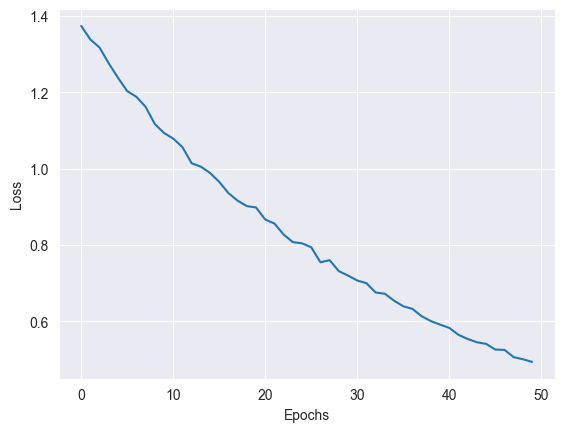

In [81]:
#graph
# plt.plot(range(epochs), rs)
# plt.xlabel('Epochs')
# plt.ylabel('R2')
# plt.show()

plt.plot(range(epochs), losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


In [82]:
model2.eval()

y_preds = []
y_trues = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        y_pred = model2(X_batch)
        y_preds.append(y_pred.cpu().numpy())   # move predictions back to CPU
        y_trues.append(y_batch.cpu().numpy())  # move true labels back to CPU

# Concatenate all batches
y_pred = np.concatenate(y_preds, axis=0)
y_true = np.concatenate(y_trues, axis=0)


In [83]:
#EVALUATING MODEL

# Compute metrics
lstm_mae = mean_absolute_error(y_test, y_pred)
lstm_mse = mean_squared_error(y_test, y_pred)
lstm_rmse = np.sqrt(mse)
lstm_r2 = r2_score(y_test, y_pred)

# Print results
print(f"Evaluation Metrics:")
print(f"MAE (Mean Absolute Error): {lstm_mae:.4f}")
print(f"MSE (Mean Squared Error): {lstm_mse:.4f}")
print(f"RMSE (Root MSE): {lstm_rmse:.4f}")
print(f"R² (R-squared): {lstm_r2:.4f}")

Evaluation Metrics:
MAE (Mean Absolute Error): 0.4654
MSE (Mean Squared Error): 0.4544
RMSE (Root MSE): 1.2808
R² (R-squared): 0.9920


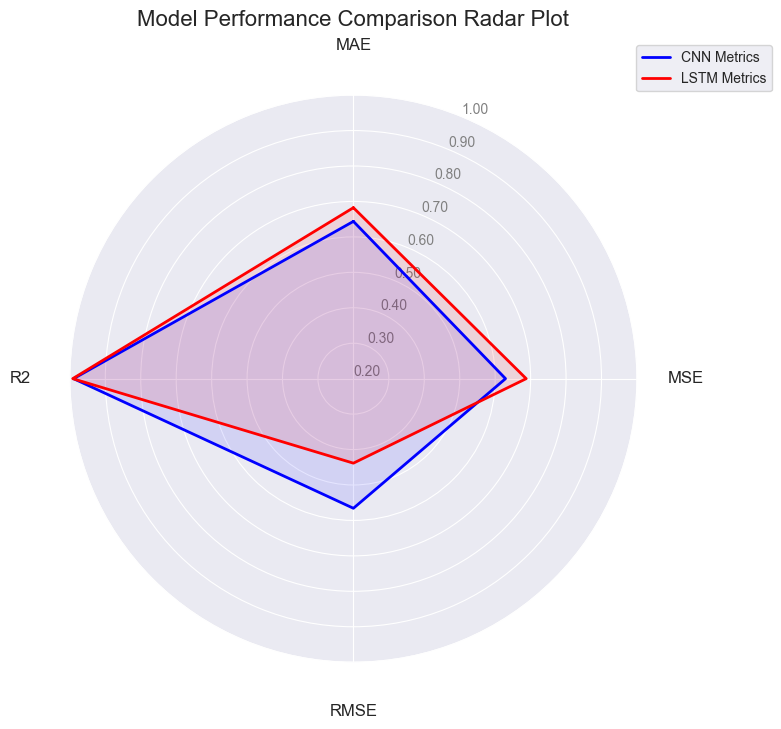

In [84]:
categories = ['MAE','MSE','RMSE','R2']
num_vars = len(categories)

cnn_mae_score = 1 / (1 + cnn_mae)
cnn_mse_score = 1 / (1 + cnn_mse)
cnn_rmse_score = 1 / (1 + cnn_rmse)

lstm_mae_score = 1 / (1 + lstm_mae)
lstm_mse_score = 1 / (1 + lstm_mse)
lstm_rmse_score = 1 / (1 + lstm_rmse)

values_cnn = [cnn_mae_score, cnn_mse_score, cnn_rmse_score, cnn_r2]
values_lstm = [lstm_mae_score, lstm_mse_score, lstm_rmse_score, lstm_r2]
# values_gru = [acc_gru, f1_gru, pre_gru, rec_gru]

values_cnn = values_cnn + [values_cnn[0]]
values_lstm = values_lstm + [values_lstm[0]]
# values_gru = values_gru + [values_gru[0]]

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, values_cnn, linewidth=2, linestyle='solid', color='blue', label='CNN Metrics')
ax.fill(angles, values_cnn, 'blue', alpha=0.1)

ax.plot(angles, values_lstm, linewidth=2, linestyle='solid', color='red', label='LSTM Metrics')
ax.fill(angles, values_lstm, 'red', alpha=0.1)

# ax.plot(angles, values_gru, linewidth=2, linestyle='solid', color='green', label='GRU Metrics')
# ax.fill(angles, values_gru, 'green', alpha=0.1)


ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.tick_params(axis='x', pad=25)

max_val = 1.0
min_val = 0.2

radial_tick_positions = np.arange(min_val, max_val + 0.1, 0.1)
radial_tick_labels = [f'{y:.2f}' for y in radial_tick_positions]

ax.set_ylim(min_val, max_val)
ax.set_yticks(radial_tick_positions)
ax.set_yticklabels(radial_tick_labels, color='grey', size=10)

ax.set_title('Model Performance Comparison Radar Plot', va='bottom', fontsize=16)

ax.grid(True)

ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))

plt.tight_layout()

# plt.savefig('graphs/metrics_radar.png')

plt.show()